# FORESEE Models: Protophobic

## Load Libraries 

In [1]:
import sys, os
src_path = "../../"
sys.path.append(src_path)

import numpy as np
from src.foresee import Foresee, Utility, Model
from matplotlib import pyplot as plt

## 1. Specifying the Model

The phenomenology of the protophobic gauge boson $A'$ can be described by the following Lagrangian

\begin{equation}
 \mathcal{L} = \frac{1}{2} \color{red}{m_{A'}}^2 A'^2  - \color{red}{g} \sum  x_f \ \bar f \gamma^\mu f A'_\mu
\end{equation}

with the dark photon mass $m_{A'}$ and the coupling $g$ as free parameters. The parameters $x_f$ specify the couplings to different fermions, in this case $x_u = -1/3$, $x_d=2/3$, $x_e=-1$ and $x_\nu=0$ for all three generations. For the search for the gauge boson at forward experiments we need to know i) the *production rate*, ii) the *lifetime* and iii) possibly the *decay branching fractions* of dark photons as function of those two parameters. All properties are specified in the `Model` class. We initialize it with the name of the model as argument. 


In [2]:
energy = "13.6"
modelname="Protophobic"
model = Model(modelname, path="./")

**Production** Most LLPs are produced in the decay of primary particles. Here we need to specify the total branching fraction into the LLP as function of the `coupling` and the `mass`. We additionally specify the variable `nsample` which specifies how often each parent particle is decayed. 

At first, let's look at the pseudo scalar decays $\pi^0, \eta, \eta' \to A' \gamma$. The corresponding branching fractions can be found in Tab. 3 of [1801.04847](https://arxiv.org/pdf/1801.04847.pdf). Notably, for the protophobic gauge boson, the decay width of $\pi^0 \to A' \gamma$ is strongly suppressed. The dominant contribution therefore comes from the $\eta$ and $\eta'$ decays.  

\begin{equation}
\begin{aligned}
    \text{BR}(\pi^0 \to A' \gamma) &\approx 0  \\
    \text{BR}(\eta \to A' \gamma)  &= 2 (g/e)^2 \times\text{BR}(\eta \to \gamma\gamma) \times 
    \left(1-m_{A'}^2/m_\eta^2\right)^3 \times [\frac{1}{8}BW_\omega(m) - \frac{9}{8} BW_\rho(m) + \frac{4}{8} BW_\phi(m)]^2 \approx  0.5 (g/e)^2 \times\text{BR}(\eta \to \gamma\gamma) \times 
    \left(1-m_{A'}^2/m_\eta^2\right)^3 \\
    \text{BR}(\eta' \to A' \gamma)  &= 2 (g/e)^2 \times\text{BR}(\eta' \to \gamma\gamma) \times \left(1-m_{A'}^2/m_{\eta'}^2\right)^3 \times [\frac{1}{14}BW_\omega(m) - \frac{9}{14} BW_\rho(m) - \frac{8}{14} BW_\phi(m)]^2  \approx 128/49 (g/e)^2 \times\text{BR}(\eta' \to \gamma\gamma) \times \left(1-m_{A'}^2/m_{\eta'}^2\right)^3 
\end{aligned}
\end{equation}

where $BW_{V} = (1-m_{A'}^2/m_V^2 - i \Gamma_V/m_V)^{-1}$.

In [3]:
model.add_production_2bodydecay(
    pid0 = "221",
    pid1 = "22",
    br = "2.*0.39 * (coupling/0.3)**2 * pow(1.-pow(mass/self.masses('221'),2),3) * np.abs(1./8.*(1-mass**2/0.78265**2 - 0.00849/0.78265*1j)**(-1) - 9./8.*(1-mass**2/0.77545**2 - 0.147/0.77545*1j)**(-1) + 4./8.*(1-mass**2/1.019461**2)**(-1))**2",
    generator = ['EPOSLHC', 'SIBYLL', 'QGSJET', 'Pythia8-Forward'],
    energy = energy,
    nsample = 1000, 
)

Dark photons can also be produced via dark Bremsstrahlung, so coherent radiation off a proton in processes such as $p p \to p p A'$. The spectra for LLPs have been exbtained following the description in [1708.09389](https://arxiv.org/abs/1708.09389) and are provided in the `files/direct` directory. As the FWW apprixmation loose validaty at high pT, we impose a cut on the pT of the dark photon and study the associated uncertainy by varing that cut as `0.5`, `1`, `2` GeV.


In [4]:
masses_brem = [ 
    0.001, 0.002, 0.003, 0.005, 0.007, 0.01 , 0.015, 0.02 , 0.03 , 
    0.04 , 0.06 , 0.08 , 0.1  , 0.14 , 0.175, 0.21 , 0.245, 0.28 ,
    0.315, 0.35 , 0.385, 0.42 , 0.455, 0.49 , 0.525, 0.56 , 0.595,
    0.63 , 0.665, 0.7  , 0.71 , 0.72 , 0.73 , 0.74 , 0.75 , 0.76 ,
    0.77 , 0.78 , 0.79 , 0.8  , 0.81 , 0.82 , 0.83 , 0.84 , 0.85 ,
    0.86 , 0.87 , 0.88 , 0.89 , 0.9  , 0.91 , 0.92 , 0.93 , 0.94 ,
    0.95 , 0.96 , 0.97 , 0.98 , 0.99 , 1.   , 1.01 , 1.02 , 1.03 ,
    1.04 , 1.05 , 1.06 , 1.07 , 1.08 , 1.09 , 1.1  , 1.12 , 1.14 ,
    1.16 , 1.18 , 1.2  , 1.22 , 1.24 , 1.26 , 1.28 , 1.3  , 1.32 ,
    1.34 , 1.36 , 1.38 , 1.4  , 1.42 , 1.44 , 1.46 , 1.48 , 1.5  ,
    1.525, 1.55 , 1.575, 1.6  , 1.625, 1.65 , 1.675, 1.7  , 1.725,
    1.75 , 1.775, 1.8  , 1.825, 1.85 , 1.875, 1.9  , 1.95 , 2.0  , 
]

# I get this error
# did not find file: ['./model/direct/13.6TeV/Brem_Model1_L0_13.6TeV_0.015.txt', 
# './model/direct/13.6TeV/Brem_Model1_Lu_13.6TeV_0.015.txt', 
# './model/direct/13.6TeV/Brem_Model1_Ld_13.6TeV_0.015.txt', 
# './model/direct/13.6TeV/Brem_Model2_L0_13.6TeV_0.015.txt', 
# './model/direct/13.6TeV/Brem_Model2_Lu_13.6TeV_0.015.txt', 
# './model/direct/13.6TeV/Brem_Model2_Ld_13.6TeV_0.015.txt', 
# './model/direct/13.6TeV/Brem_Model3_L0_13.6TeV_0.015.txt', 
# './model/direct/13.6TeV/Brem_Model3_Lu_13.6TeV_0.015.txt', 
# './model/direct/13.6TeV/Brem_Model3_Ld_13.6TeV_0.015.txt'] 
# or ['./model/direct/13.6TeV/Brem_Model1_L0_13.6TeV_0.02.txt', 
# './model/direct/13.6TeV/Brem_Model1_Lu_13.6TeV_0.02.txt', 
# './model/direct/13.6TeV/Brem_Model1_Ld_13.6TeV_0.02.txt', 
# './model/direct/13.6TeV/Brem_Model2_L0_13.6TeV_0.02.txt', 
# './model/direct/13.6TeV/Brem_Model2_Lu_13.6TeV_0.02.txt', 
# './model/direct/13.6TeV/Brem_Model2_Ld_13.6TeV_0.02.txt', 
# './model/direct/13.6TeV/Brem_Model3_L0_13.6TeV_0.02.txt', 
# './model/direct/13.6TeV/Brem_Model3_Lu_13.6TeV_0.02.txt', 
# './model/direct/13.6TeV/Brem_Model3_Ld_13.6TeV_0.02.txt']

masses_brem = [ 
    0.001, 0.002, 0.003, 0.005 , 
    0.04 , 0.06 , 0.08 , 0.1  , 0.14 , 0.175, 0.21 , 0.245, 0.28 ,
    0.315, 0.35 , 0.385, 0.42 , 0.455, 0.49 , 0.525, 0.56 , 0.595,
    0.63 , 0.665, 0.7  , 0.71 , 0.72 , 0.73 , 0.74 , 0.75 , 0.76 ,
    0.77 , 0.78 , 0.79 , 0.8  , 0.81 , 0.82 , 0.83 , 0.84 , 0.85 ,
    0.86 , 0.87 , 0.88 , 0.89 , 0.9  , 0.91 , 0.92 , 0.93 , 0.94 ,
    0.95 , 0.96 , 0.97 , 0.98 , 0.99 , 1.   , 1.01 , 1.02 , 1.03 ,
    1.04 , 1.05 , 1.06 , 1.07 , 1.08 , 1.09 , 1.1  , 1.12 , 1.14 ,
    1.16 , 1.18 , 1.2  , 1.22 , 1.24 , 1.26 , 1.28 , 1.3  , 1.32 ,
    1.34 , 1.36 , 1.38 , 1.4  , 1.42 , 1.44 , 1.46 , 1.48 , 1.5  ,
    1.525, 1.55 , 1.575, 1.6  , 1.625, 1.65 , 1.675, 1.7  , 1.725,
    1.75 , 1.775, 1.8  , 1.825, 1.85 , 1.875, 1.9  , 1.95 , 2.0  , 
]

model.add_production_direct(
    label = "Brem_QRA",
    energy = energy,
    condition = None,
    configuration = [
        "Brem_Model1_L0","Brem_Model1_Lu","Brem_Model1_Ld",
        "Brem_Model2_L0","Brem_Model2_Lu","Brem_Model2_Ld",
        "Brem_Model3_L0","Brem_Model3_Lu","Brem_Model3_Ld",
    ],
    coupling_ref=0.303,
    masses = masses_brem,
)


#model.add_production_direct(
#    label = "Brem_FWW",
#    energy = energy,
#    condition = ["p.pt<1", "p.pt<2", "p.pt<0.5", "1"],
#    configuration = ["Brem_FWW"],
#    coupling_ref=1,
#    masses = masses_brem,
#)

#model.add_production_direct(
#    label = "Brem_QRA",
#    energy = energy,
#    condition = None,
#    configuration = ["Brem_QRAD_1","Brem_QRAD_1.5","Brem_QRAD_2"],
#    coupling_ref=1,
#    masses = masses_brem,
#)

In [5]:
masses_brem_tan = [
    0.01, 0.02, 0.03, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.55, 
    0.60, 0.65, 0.70, 0.73, 0.75, 0.77, 0.79, 0.82, 0.85, 0.90, 
    0.95, 1.00, 1.10, 1.20, 1.30, 1.40, 1.50, 1.60, 1.70, 1.80, 
    1.90, 2.00 
]

model.add_production_direct(
    label = "Brem_TAN",
    energy = energy,
    condition = None,
    configuration = [
        "BremTAN_EPOSLHC_Model1_L0", "BremTAN_EPOSLHC_Model1_Lu", "BremTAN_EPOSLHC_Model1_Ld",
        "BremTAN_SIBYLL_Model1_L0" , "BremTAN_QGSJET_Model1_L0" , 
        "BremTAN_EPOSLHC_Model2_L0", "BremTAN_EPOSLHC_Model3_L0", 
    ],
    coupling_ref=0.303,
    masses = masses_brem_tan,
)

At high masses, the production of dark photons is dominated by Drell-Yan production, so quark-anti-quark fusion $q q \to A' + X$. Here we use the dark photon spectra obtained in [1810.01879](https://arxiv.org/pdf/1810.01879.pdf) using MadGraph plus Pythia, which are provided in the `files/direct` directory. 

In [6]:
#masses_dy = [1.5849, 1.7783, 1.9953,2.2387, 2.5119, 2.8184, 3.1623, 3.9811, 5.0119, 6.3096, 7.9433, 10.]
#model.add_production_direct(
#    label = "DY",
#    energy = energy,
#    coupling_ref=1,
#    masses = masses_dy,
#    condition='True',
#)

**Decay:** Dark photons can decay into all kinematically accessible light charged states, with a decay width proportional to $\epsilon^2$. Here we use the lifetime and the decay branching fractions as presented in [1801.04847](https://arxiv.org/abs/1801.04847) for the DarkCast tool. 

In [7]:
model.set_ctau_1d(
    filename="model/ctau.txt", 
)

decay_modes = ["bfrac_elec"] 
model.set_br_1d(
    modes = decay_modes,
    finalstates=[[11,-11]],
    filenames=["model/br/"+mode+".txt" for mode in decay_modes],
)

We can now initiate FORESEE with the model that we just created. 

In [8]:
foresee = Foresee(path=src_path)
foresee.set_model(model=model)

## 2. Event Generation

In the following, we want to study one specific benchmark point with $m_{A'}=50$ MeV and $\epsilon=3\cdot 10^{-5}$ and export events as a HEPMC file. 

In [9]:
mass, coupling, = 0.017, 2e-5

First, we will produce the corresponding flux for this mass and a reference coupling $\epsilon_{ref}=1$. 

save data to file: ./model/LLP_spectra/13.6TeV_221_EPOSLHC_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_221_SIBYLL_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_221_QGSJET_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_221_Pythia8-Forward_m_0.017.npy
did not find file: ['./model/direct/13.6TeV/Brem_Model1_L0_13.6TeV_0.005.txt', './model/direct/13.6TeV/Brem_Model1_Lu_13.6TeV_0.005.txt', './model/direct/13.6TeV/Brem_Model1_Ld_13.6TeV_0.005.txt', './model/direct/13.6TeV/Brem_Model2_L0_13.6TeV_0.005.txt', './model/direct/13.6TeV/Brem_Model2_Lu_13.6TeV_0.005.txt', './model/direct/13.6TeV/Brem_Model2_Ld_13.6TeV_0.005.txt', './model/direct/13.6TeV/Brem_Model3_L0_13.6TeV_0.005.txt', './model/direct/13.6TeV/Brem_Model3_Lu_13.6TeV_0.005.txt', './model/direct/13.6TeV/Brem_Model3_Ld_13.6TeV_0.005.txt'] or ['./model/direct/13.6TeV/Brem_Model1_L0_13.6TeV_0.04.txt', './model/direct/13.6TeV/Brem_Model1_Lu_13.6TeV_0.04.txt', './model/direct/13.6TeV/Brem_Model1_Ld_

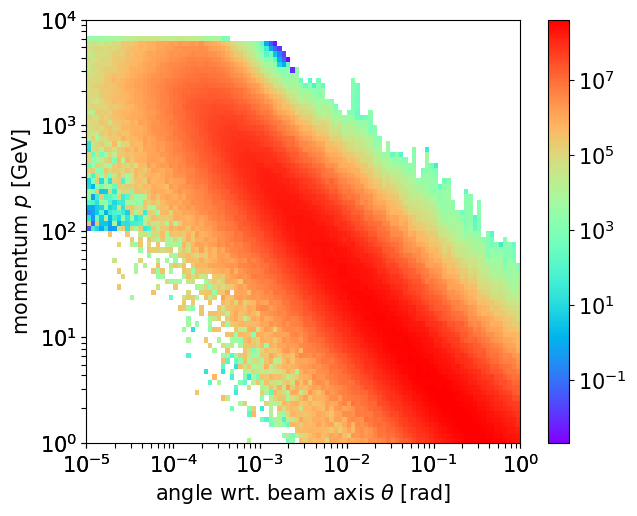

In [10]:
plot=foresee.get_llp_spectrum(mass=mass, coupling=1, do_plot=True)
plot.show()

Next, let us define the configuration of the detector (in terms of position, size and luminosity). Here we choose FASER.

In [11]:
foresee.set_detector(
    distance=480, 
    selection="np.sqrt((x.x)**2 + (x.y)**2)<0.1",    
    length=4, 
    luminosity=190, 
    # channels=[""]
)

For our benchmark point, let us now look at how many particle decay inside the decay volume. We also export 1000 unweighted events as a HEPMC file. 

In [12]:
setupnames = ['EPOSLHC']
modes = {
    '221':['EPOSLHC',], 
    "Brem_QRA": ["Brem_Model1_L0"],
    "Brem_TAN": ["BremTAN_EPOSLHC_Model1_L0"],
}

momenta, weights, _ = foresee.write_events(
    mass = mass, 
    coupling = coupling, 
    energy = energy, 
    numberevent = 1000,
    filename = "model/events/test.hepmc", 
    return_data = True,
    weightnames=setupnames,
    modes=modes,
    nsample=30,
)

for isetup, setup in enumerate(setupnames):
    print("Expected number of events for "+setup+":", round(sum(weights[:,isetup]),3))

Expected number of events for EPOSLHC: 89.475


Let us plot the resulting energy distribution

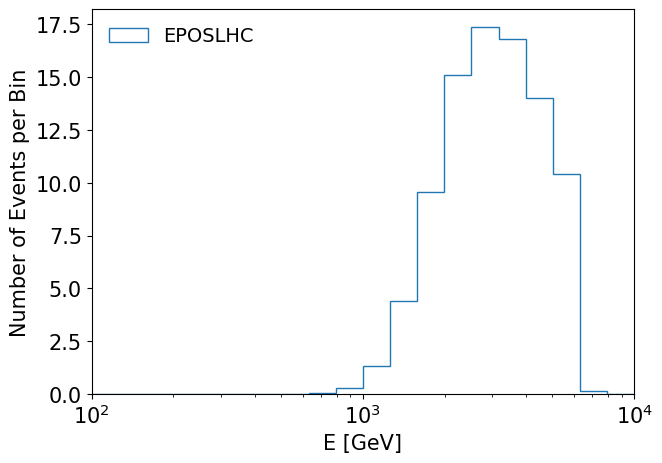

In [13]:
fig = plt.figure(figsize=(7,5))
ax = plt.subplot(1,1,1)
energies = [p.e for p in momenta], 
for isetup, setup in enumerate(setupnames):
    ax.hist(energies, weights=weights[:,isetup], bins=np.logspace(2,4, 20+1), histtype='step', label=setup) 
ax.set_xscale("log")
ax.set_xlim(1e2,1e4) 
ax.set_xlabel("E [GeV]") 
ax.set_ylabel("Number of Events per Bin") 
ax.legend(frameon=False, labelspacing=0, fontsize=14, loc='upper left')
plt.show()

## 3. Sensitivity Reach

In the following, we will obtain the projected sensitivity for the LLP model. For this, we first define a grid of couplings and masses, and then produce the corresponding fluxes. 

In [14]:
masses=[round(x,5) for x in np.logspace(-2,0.3,46+1)]
couplings = np.logspace(-9,-3,101) 

for mass in masses: foresee.get_llp_spectrum(mass=mass,coupling=1)

save data to file: ./model/LLP_spectra/13.6TeV_221_EPOSLHC_m_0.01.npy
save data to file: ./model/LLP_spectra/13.6TeV_221_SIBYLL_m_0.01.npy
save data to file: ./model/LLP_spectra/13.6TeV_221_QGSJET_m_0.01.npy
save data to file: ./model/LLP_spectra/13.6TeV_221_Pythia8-Forward_m_0.01.npy
did not find file: ['./model/direct/13.6TeV/Brem_Model1_L0_13.6TeV_0.005.txt', './model/direct/13.6TeV/Brem_Model1_Lu_13.6TeV_0.005.txt', './model/direct/13.6TeV/Brem_Model1_Ld_13.6TeV_0.005.txt', './model/direct/13.6TeV/Brem_Model2_L0_13.6TeV_0.005.txt', './model/direct/13.6TeV/Brem_Model2_Lu_13.6TeV_0.005.txt', './model/direct/13.6TeV/Brem_Model2_Ld_13.6TeV_0.005.txt', './model/direct/13.6TeV/Brem_Model3_L0_13.6TeV_0.005.txt', './model/direct/13.6TeV/Brem_Model3_Lu_13.6TeV_0.005.txt', './model/direct/13.6TeV/Brem_Model3_Ld_13.6TeV_0.005.txt'] or ['./model/direct/13.6TeV/Brem_Model1_L0_13.6TeV_0.04.txt', './model/direct/13.6TeV/Brem_Model1_Lu_13.6TeV_0.04.txt', './model/direct/13.6TeV/Brem_Model1_Ld_13.6

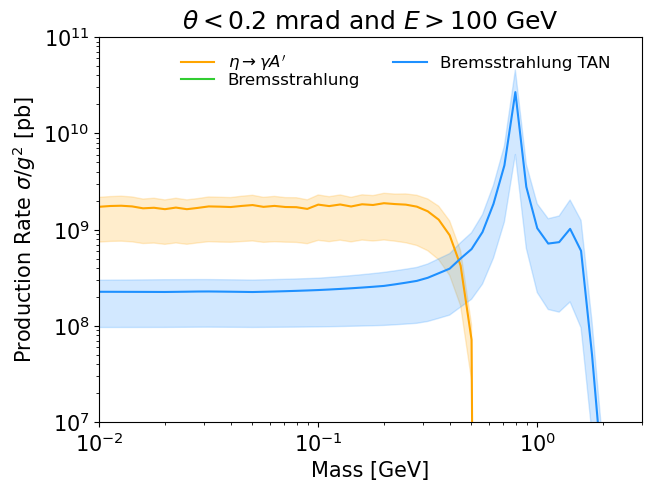

In [15]:
productions=[
    {"channels": ["221"]     , "color": "orange"    , "label": r"$\eta \to \gamma A'$" , "generators": ["EPOSLHC","QGSJET","SIBYLL"]  },
    {"channels": ["Brem_QRA"], "color": "limegreen" , "label": r"Bremsstrahlung"       , "generators": ["Brem_Model1_L0", "Brem_Model1_Lu", "Brem_Model1_Ld"]},
    {"channels": ["Brem_TAN"], "color": "dodgerblue", "label": r"Bremsstrahlung TAN"   , "generators": ["BremTAN_EPOSLHC_Model1_L0", "BremTAN_EPOSLHC_Model1_Lu", "BremTAN_EPOSLHC_Model1_Ld"]},
]

plot=foresee.plot_production(
    masses = masses,
    productions = productions,
    energy=energy,
    condition="logth<-3.7 and logp>2",  
    xlims=[0.01,3],ylims=[1e7,1e11],
    xlabel=r"Mass [GeV]",
    ylabel=r"Production Rate $\sigma/g^2$ [pb]",
    title=r"$\theta < 0.2$ mrad and $E > 100$ GeV",
    legendloc=(0.97,1),
    fs_label=12,
    ncol=2,
)

plot.savefig("photon_production_channels_E100.pdf")
plot.show()

In [16]:
bounds2 = [ 
    ["bounds_Anomaly.txt",    "Anomaly",  0.025, 1e-4, 0  ],
]
bounds = [ 
    ["bounds_Orsay_Davier1989wz.txt"          , "Orsay", 0.042 , 2.5*10**-6 , -28],
    ["bounds_E141_Riordan1987aw.txt"          , "E141",  0.011 , 1.8*10**-5 , 0  ],
    ["bounds_NA64_Banerjee2019hmi.txt"        , "NA64",  0.014 , 1.0*10**-4 , -35],
    ["bounds_KLOE_Anastasi2015qla.txt"        , "KLOE",  0.011 , 7.0*10**-4 , 0  ],
    ["bounds_BaBar_Lees2014xha.txt"           , "BaBar", 0.060 , 7.0*10**-4 , 0  ],
    ["bounds_PADME.txt"                       , "PADME", 0.018 , 3*10**-4 , 0],
]

In [17]:
setups = [ 
    ["13.6TeV_meson_EPOSLHC.npy", "only $\eta$-decay"    , "red"        ,  "dashed"  , 0, 3.6],
   ["13.6TeV_qra_EPOSLHC.npy",   "incl. proton Bremsstrahlung" , "limegreen" ,  "dashdot"  , 0, 3.6],
   ["13.6TeV_meson_EPOSLHC.npy", "FASER Paper" , "red"        ,  "solid"  , 0, 3.6],
    ["13.6TeV_all_EPOSLHC.npy",   "incl. Bremsstrahlung" , "dodgerblue" ,  "solid"  , 0, 3.6],
]

<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:2: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_81932/3130729452.py:2: SyntaxWarning: invalid escape sequence '\e'
  ["13.6TeV_meson_EPOSLHC.npy", "only $\eta$-decay"    , "red"        ,  "dashed"  , 0, 3.6],


In [18]:
def plot_band(setup0, setup1, nevents=3):
    foresee.extract_contours("model/results/"+setup0,"model/lines/limits_0.txt",nevents=nevents)
    foresee.extract_contours("model/results/"+setup1,"model/lines/limits_1.txt",nevents=nevents)
    data0 = foresee.readfile("model/lines/limits_0.txt")
    data1 = foresee.readfile("model/lines/limits_1.txt")
    data=[]
    for x, y in data0: data.append([x,y])
    for x, y in np.flip(data1,0): data.append([x,y])
    return np.array(data)

data1=plot_band("13.6TeV_meson_EPOSLHC.npy", "13.6TeV_meson_QGSJET.npy",nevents=3.6)
data2=plot_band("13.6TeV_qra_SIBYLL.npy", "13.6TeV_qra_QGSJET.npy",nevents=3.6)
data3=plot_band("13.6TeV_all_SIBYLL.npy", "13.6TeV_all_QGSJET.npy",nevents=3.6)

IndexError: index 0 is out of bounds for axis 0 with size 0

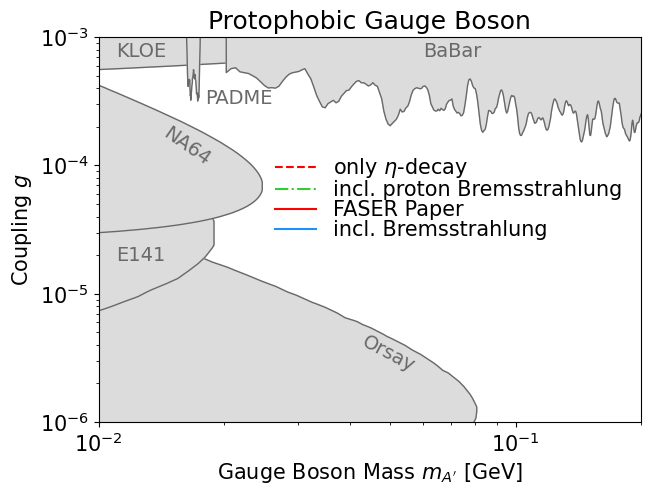

In [19]:
plot = foresee.plot_reach(
    setups=setups,
    bounds=bounds,
    # bounds2=bounds2,
    projections=[],
    branchings=None,
    title="Protophobic Gauge Boson", 
    xlims = [0.01,0.20], 
    ylims=[1e-6,0.001],
    xlabel=r"Gauge Boson Mass $m_{A'}$ [GeV]", 
    ylabel=r"Coupling $g$",
    legendloc=(1.0,0.74),
    figsize=(7,5),
)

plot.fill(data1.T[0], data1.T[1], color='red', alpha=0.2)
plot.fill(data2.T[0], data2.T[1], color='limegreen', alpha=0.2)
plot.fill(data3.T[0], data3.T[1], color='dodgerblue', alpha=0.2)
plot.plot([0.0169,0.0169],[1e-6,0.002],ls='dotted', c='k')

plot.subplots_adjust(left=0.13, right=0.975, bottom=0.115, top=0.935)
plot.savefig("Reach_"+modelname+".pdf")
plot.show()

In [ ]:
np.load("model/results/13.6TeV_all_EPOSLHC.npy", allow_pickle=True)